In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **EXTRACCIÓN Y TRANSFORMACIÓN DE DATOS**

Para todas las partes de esta evidencia, estaré trabajando con 3 bases de datos diferentes, así que colocaré el proceso de extracción y transformación de datos de todas ellas en esta sección.

1. **Base de bitácora de piso**

In [312]:
# Carga desde un archivo .csv sin indice
bp = pd.read_csv('Bitacora_piso.csv') 

In [313]:
# Verificamos información del DataFrame
bp.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [314]:
# Limpiar los nombres de las columnas eliminando espacios en blanco al inicio y al final
bp.columns = bp.columns.str.strip()

In [315]:
# Cambiar algunos tipos de datos para que sean más adecuados
bp['SDC'] = bp['SDC'].astype(bool)
bp['Venta'] = bp['Venta'].astype(bool)
bp['Inter Gerente'] = bp['Inter Gerente'].astype(bool)

In [316]:
# Eliminar columnas innecesarias (sin ningún dato)
bp = bp.drop(columns=['Telefono', 'Estatus de SDC','Temperatura', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'])

In [317]:
# Eliminar filas vacías
bp = bp.drop(bp.index[207:236])

In [318]:
# Revisar la columna de asesor, porque hay duplicados o inconsistencias en los nombres
bp["Asesor"].unique()

<StringArray>
[              'Aurelio',                 'Pedro',              'Mauricio',
                 'Alan ',                'Victor',              'Ricardo ',
               'Eduardo',                 'Laura',                     nan,
                 'Nancy',               'Ricardo',               'AUrelio',
       'Nancy OLascoaga',                  'Alan',               'Victor ',
         'Pedro Antonio', 'Victor Manuel Sanchez',        'Alan González ',
        'Aurelio Torres',       'Pedro González ',      'Mauricio Vazquez',
         'Alan González',        'Victor Manuel ',     'Mauricio Vazquez ',
  'Pedro Antonio Cinto ',                  'Casa',       'Victor Sanchez ',
       'Aurelio Torres ',        'Alan Gonzalez ',        'Ricardo Silva ',
           'Marcos Coca',       'Pedro Gonzalez ',        'Miguel Ramírez',
      'Mauricio Vázquez',       'Miguel Ramírez ']
Length: 35, dtype: str

In [319]:
# Corrección de los nombres de asesores
correccion = {
    'Aurelio': 'Aurelio Torres',
    'AUrelio': 'Aurelio Torres',
    'Aurelio Torres': 'Aurelio Torres',

    'Mauricio': 'Mauricio Vázquez',
    'Mauricio Vazquez': 'Mauricio Vázquez',
    'Mauricio Vázquez': 'Mauricio Vázquez',

    'Alan': 'Alan González',
    'Alan González': 'Alan González',
    'Alan Gonzalez': 'Alan González',

    'Victor': 'Victor Manuel Sánchez',
    'Victor Manuel Sanchez': 'Victor Manuel Sánchez',
    'Victor Manuel': 'Victor Manuel Sánchez',
    'Victor Sanchez': 'Victor Manuel Sánchez',

    'Ricardo': 'Ricardo Silva',
    'Ricardo Silva': 'Ricardo Silva',

    'Nancy': 'Nancy Olascoaga',
    'Nancy OLascoaga': 'Nancy Olascoaga',

    'Pedro González': 'Pedro González',
    'Pedro': 'Pedro González',
    'Pedro Gonzalez': 'Pedro González',
    'Pedro Antonio Cinto': 'Pedro Antonio Cinto',

    'Miguel Ramírez': 'Miguel Ramírez',
    'Marcos Coca': 'Marcos Coca',
    'Eduardo': 'Eduardo',
    'Laura': 'Laura',
}

bp['Asesor'] = bp['Asesor'].str.strip().replace(correccion)

In [320]:
# Volver a checar los valores únicos de la columna "Asesor" después de la corrección
bp["Asesor"].unique()

<StringArray>
[       'Aurelio Torres',        'Pedro González',      'Mauricio Vázquez',
         'Alan González', 'Victor Manuel Sánchez',         'Ricardo Silva',
               'Eduardo',                 'Laura',                     nan,
       'Nancy Olascoaga',         'Pedro Antonio',   'Pedro Antonio Cinto',
                  'Casa',           'Marcos Coca',        'Miguel Ramírez']
Length: 15, dtype: str

In [321]:
# Guardar el archivo limpio en un nuevo archivo CSV
bp.to_csv("bp_limpio.csv", index=False)

In [322]:
# Verificar otra vez
bp.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Fecha                                       196 non-null    str  
 1   Nombre Cliente                              196 non-null    str  
 2   Asesor                                      195 non-null    str  
 3   Esatus Lead                                 196 non-null    str  
 4   PDM                                         207 non-null    bool 
 5   SDC                                         207 non-null    bool 
 6   Venta                                       207 non-null    bool 
 7   Inter Gerente                               207 non-null    bool 
 8   ¿Por que no hubo prueba de manejo?          16 non-null     str  
 9   ¿Por que no hubo Solicitud de credito?      14 non-null     str  
 10  ¿Por que no hubo intervencion del Gerente?  11 no

2. **Base de Principales Canales**

La base estaba muy rara, los indicadores y canales estaban en una sola columna, primero en una fila venía el canal, después sus indicadores, después unas filas vacías, y se repetía así por canal, todo en la misma hoja. Algunas filas de hasta arriba eran solo la sumatoria por columna, por eso se cargo sin nombres de columnas asignadas.

In [323]:
# Carga desde un archivo .csv
df= pd.read_csv("Canales.csv", header=None)

In [324]:
# Verificamos información del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 60 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       47 non-null     str    
 1   1       37 non-null     str    
 2   2       38 non-null     str    
 3   3       40 non-null     str    
 4   4       40 non-null     str    
 5   5       41 non-null     str    
 6   6       42 non-null     str    
 7   7       41 non-null     str    
 8   8       42 non-null     str    
 9   9       41 non-null     str    
 10  10      41 non-null     str    
 11  11      42 non-null     str    
 12  12      43 non-null     str    
 13  13      46 non-null     str    
 14  14      46 non-null     str    
 15  15      46 non-null     str    
 16  16      46 non-null     str    
 17  17      43 non-null     str    
 18  18      43 non-null     str    
 19  19      45 non-null     str    
 20  20      45 non-null     str    
 21  21      45 non-null     str    
 22  22      45 non-

In [325]:
# Convertir meses y años de las 24 columnas (12 de 2025 + 12 de 2026)
meses = df.iloc[6, 1:31].tolist()

In [326]:
# Dividir por secciones, según el canal, usando .loc para seleccionar las filas y columnas correspondientes a cada canal.
# Se usó .T para transponer el DataFrame y que los indicadores sean columnas, lo demás como observaciones, agregando canal y periodo como columnas
#Piso
piso = df.loc[[7, 8, 9, 10, 11, 12, 13, 14, 15], 0:30].set_index(0).T
piso.columns = piso.columns.str.strip()
piso.columns.name = None
piso['Periodo'] = meses
piso['Canal'] = 'Piso'

# plazas
plazas = df.loc[[20, 21, 22, 23, 24, 26, 28, 29, 30], 0:30].set_index(0).T
plazas.columns = plazas.columns.str.strip()
plazas.columns.name = None
plazas['Periodo'] = meses
plazas['Canal'] = 'Plazas'

# digital
digital = df.loc[[35, 36, 37, 38, 39, 40, 41, 42, 43], 0:30].set_index(0).T
digital.columns = digital.columns.str.strip()
digital.columns.name = None
digital['Periodo'] = meses
digital['Canal'] = 'Digital'

In [327]:
# Unir las secciones
df = pd.concat([piso, plazas, digital], ignore_index=True)

In [328]:
# Limpieza de datos y conversión de tipos de datos
# Limpiar %
df[['Conversion', 'Aporte']] = df[['Conversion', 'Aporte']].replace('%', '', regex=True).astype(float) / 100

# Limpiar "-"
df = df.replace('-', pd.NA)

#Pasar a numericas
cols_num = ['Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas', 'Ventas']
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')

# Espacios en nombres de columnas
df.columns = df.columns.str.strip()

In [329]:
# Verificar otra vez
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Leads              90 non-null     int64  
 1   Efectivos          43 non-null     float64
 2   SDC                64 non-null     float64
 3   PDM                81 non-null     float64
 4   Citas Programadas  88 non-null     float64
 5   Citas Efectivas    87 non-null     float64
 6   Ventas             86 non-null     float64
 7   Conversion         90 non-null     float64
 8   Aporte             90 non-null     float64
 9   Periodo            90 non-null     str    
 10  Canal              90 non-null     str    
dtypes: float64(8), int64(1), str(2)
memory usage: 7.9 KB


In [330]:
# Guardar el archivo limpio en un nuevo archivo CSV
df.to_csv("canales_limpio.csv", index=False)

3. **Base de SDC de ventas**


In [331]:
# Carga desde un archivo .csv
sdc = pd.read_csv("SDC_Ventas.csv", header=None)


In [332]:
# Verificamos información del DataFrame
sdc.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       12 non-null     str  
 1   1       12 non-null     str  
 2   2       12 non-null     str  
 3   3       12 non-null     str  
 4   4       12 non-null     str  
 5   5       12 non-null     str  
 6   6       12 non-null     str  
 7   7       12 non-null     str  
 8   8       12 non-null     str  
 9   9       12 non-null     str  
 10  10      12 non-null     str  
 11  11      12 non-null     str  
 12  12      12 non-null     str  
 13  13      12 non-null     str  
 14  14      12 non-null     str  
 15  15      12 non-null     str  
 16  16      12 non-null     str  
 17  17      12 non-null     str  
 18  18      12 non-null     str  
 19  19      12 non-null     str  
 20  20      12 non-null     str  
 21  21      12 non-null     str  
 22  22      12 non-null     str  
 23  23      12 non-null     str 

In [333]:
# Dejar la primera fila como encabezado y eliminar las filas vacías
sdc.columns = sdc.iloc[1]
sdc = sdc.iloc[2:].reset_index(drop=True)
sdc.columns.name = None
sdc = sdc.iloc[0:7, 0:32]

In [334]:
# Sacar lo de los meses
periodos = sdc.columns[1:].tolist()
periodos

['Enero, 24',
 'Febrero, 24',
 'Marzo, 24',
 'Abril, 24',
 'Mayo, 24',
 'Junio, 24',
 'Julio, 24',
 'Agosto, 24',
 'Septiembre, 24',
 'Octubre, 24',
 'Noviembre, 24',
 'Diciembre, 25',
 'Enero, 25',
 'Febrero, 25',
 'Marzo, 25',
 'Abril, 25',
 'Mayo, 25',
 'Junio, 25',
 'Julio, 25',
 'Agosto, 25',
 'Septiembre, 25',
 'Octubre, 25',
 'Noviembre, 25',
 'Diciembre, 25',
 'Enero, 26',
 'Febrero, 26',
 'Marzo, 26',
 'Abril, 26',
 'Mayo,26',
 'Junio, 26',
 'Julio,26']

In [335]:
# Corregir uno de los meses que se puso mal
cols = sdc.columns.tolist()
cols[12] = 'Diciembre, 24'
sdc.columns = cols

In [336]:
# Transponer columnas y filas
sdc = sdc.set_index('Indicador').T
sdc['Periodo'] = periodos
sdc = sdc.reset_index(drop=True)

# Espacios en nombres de columnas
sdc.columns = sdc.columns.str.strip()

In [337]:
# Cambiamos el tipo de datos a numéricos
num = ["Generadas", "Aprobadas", "Condicionadas", "Rechazadas", "Formalizadas", "% de Aprobación", "% de Formalizacion"]
sdc[num] = sdc[num].apply(pd.to_numeric, errors='coerce')

In [338]:
# Verificamos otra vez
sdc.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Generadas           31 non-null     int64  
 1   Aprobadas           31 non-null     int64  
 2   Condicionadas       31 non-null     int64  
 3   Rechazadas          31 non-null     int64  
 4   Formalizadas        31 non-null     int64  
 5   % de Aprobación     31 non-null     float64
 6   % de Formalizacion  31 non-null     float64
 7   Periodo             31 non-null     str    
dtypes: float64(2), int64(5), str(1)
memory usage: 2.1 KB


In [339]:
# Guardar el archivo limpio en un nuevo archivo CSV
sdc.to_csv("SDC_ventas_limpio.csv", index=False)

**LIMPIEZA DE NULOS**
- La base de sdc se ve sin nulos.
- La base de canales si tiene nulos, pero se decidió no trabajarlos ya que necesitamos la información exacta para el análisis, rellenarlos con un string no es lo ideal ya que son numéricas. Además, hay algunas que no tienen datos porque se empezó a llevar su registro después que las otras, así que rellenar los nulos sería inventar datos para esos periodos en los que no se tenía registro aún, distorcionando el análisis. Adicional a ello, si decidieramos quitar los nulos podríamos perder información vital. Sí se llegó a hacer algo con los nulos, pero se verá más adelante en la etapa de regresiones, por el momento, solo se llenaron los espacios vacíos con NA, en el paso anterior.
- La base de bitácora de piso si tenía nulos, y se trató con string.

1. Base bitácora de piso

In [340]:
# Verificar si hay valores nulos en el DataFrame
bp.isnull().sum()

Fecha                                          11
Nombre Cliente                                 11
Asesor                                         12
Esatus Lead                                    11
PDM                                             0
SDC                                             0
Venta                                           0
Inter Gerente                                   0
¿Por que no hubo prueba de manejo?            191
¿Por que no hubo Solicitud de credito?        193
¿Por que no hubo intervencion del Gerente?    196
¿Por que no hubo proceso wow?                 195
¿Por que no se ha formalizado la compra?      196
5 porques clientes de piso                    199
Comentarios                                   185
dtype: int64

In [341]:
# Remplazar nulos con string
bp['Fecha'] = bp['Fecha'].fillna('Sin fecha')
bp['Nombre Cliente'] = bp['Nombre Cliente'].fillna('Sin datos')
bp['Asesor'] = bp['Asesor'].fillna('Sin datos')
bp['Esatus Lead'] = bp['Esatus Lead'].fillna('Sin datos')
bp['¿Por que no hubo prueba de manejo?'] = bp['¿Por que no hubo prueba de manejo?'].fillna('Sin comentarios')
bp['¿Por que no hubo Solicitud de credito?'] = bp['¿Por que no hubo Solicitud de credito?'].fillna('Sin comentarios')
bp['¿Por que no hubo intervencion del Gerente?'] = bp['¿Por que no hubo intervencion del Gerente?'].fillna('Sin comentarios')
bp['¿Por que no hubo proceso wow?'] = bp['¿Por que no hubo proceso wow?'].fillna('Sin comentarios')
bp['¿Por que no se ha formalizado la compra?'] = bp['¿Por que no se ha formalizado la compra?'].fillna('Sin comentarios')
bp['5 porques clientes de piso'] = bp['5 porques clientes de piso'].fillna('Sin razones')
bp['Comentarios'] = bp['Comentarios'].fillna('Sin comentarios')

In [342]:
# Volver a revisar los nulos después de la limpieza
bp.isnull().sum()

Fecha                                         0
Nombre Cliente                                0
Asesor                                        0
Esatus Lead                                   0
PDM                                           0
SDC                                           0
Venta                                         0
Inter Gerente                                 0
¿Por que no hubo prueba de manejo?            0
¿Por que no hubo Solicitud de credito?        0
¿Por que no hubo intervencion del Gerente?    0
¿Por que no hubo proceso wow?                 0
¿Por que no se ha formalizado la compra?      0
5 porques clientes de piso                    0
Comentarios                                   0
dtype: int64

Como ejemplo de otro método para tratar nulos, se puede ver los siguientes fragmentos de código, los cuales saqué de varios de mis propios archivos de código de mis repositorios, de otras de las bases del socio formador.
- Imputar nulos con ffill: leads reales, Actividad 5.1

leadsr["Año"] = leadsr["Año"].ffill()
- Imputar con mediana: base de citas digitales, archivo valores_nulos, Actividad 2.1

data3["Potencial de compra"]=data3["Potencial de compra"].fillna(round(data3["Potencial de compra"].median(),1))
- Imputar con media: base de citas digitales, archivo valores_nulos, Actividad 2.1

data3["Venta"]=data3["Venta"].fillna(round(data3["Venta"].mean(),1))

# **VALORES ATÍPICOS - OUTLIERS**
Este es otro punto que en ninguna de las bases de datos se realizó. Sin embargo, hay una justificación del porqué. 
- Base canales: en este caso, nuestras columnas numéricas llevan los registros de leads, solicitudes de crédito, pruebas de manejo y citas, por lo que las cantidades dependen mucho de la actividad que se tuvo en el mes, por eso en algunos se ven números altos, mientras que en otros no. Por ello, tratar a los valores altos o bajos como extremos podría hacernos perder información clave, cómo que canales tienen mayor actividad, si hay estacionalidad, entre otros factores. Por otro lado, las columnas float ambas salen en base a fórmulas de las demás, estando todas entre valores del 0 y 1, por lo que no hay valores átipicos tampoco.
- Base de bitácora de piso: se tienen solo columnas con tipos booleanos y de cadena.
- Base SDC: Al igual que con canales, dependen del registro de los datos, y varía mucho dependiendo el mes. Las columnas tipo float igual salen de fórmulas con la información del resto de la base, pero estan dentro de un rango adecuado (0-1).

No realicé tratamiento de valores atípicos en ninguna de las bases, ya que la mayoría de las bases usadas, tanto de forma individual, como por el equipo, giraban en torno al registro de leads. En ese caso, depende mucho de como hayan llevado el registro de leads. Por ejemplo, en las bases de leads_piso de 2024 y 2025 (Actividad 2.2 y 3.2), era el registro por asesor de los leads cada mes. Por ello, hay varias filas que tienen 0 registros, y de la nada algunas en diciembre con más de 200 registros. Creo que se debe, según lo comentado en las sesiones con el socio formador, a que algunas veces los asesores registraban los leads no cada mes, si no que se les pasaba y luego ponían los leads acumulados. Igual, se podría deber a que cierto asesor no había entrado en ciertas fechas, por lo que sus primeras fechas no tendrían registros. Por todo esto se decidió no trabajar los valores como atípicos.

Sin embargo, hubo una base en la que sí se realizó el tratamiento de outliers, aunque la información de esa base no fue relevante para ningún análisis posterior. Sin embargo, dejo el fragmento de código aquí en el markdown para que se pueda ver cómo es un proceso de tratamiento de outliers (base: citas digitales, actividad 3.1).

- Creo 2 dataframe para poder procesar los outliers

cualitativas= data.iloc[ : , list(range(0, 5)) + list(range(9, 17))]

cuantitativas= data.iloc[ : , 5:9]

cuantitativas.head(5)

- Realizamos diagrama de caja o bigote de cada columna del dataframe

fig = plt.figure(figsize =(15, 8))

cuantitativas.plot(kind='box', vert=False)

plt.title("Valores Atípicos del Dataframe")

plt.show() #dibujamos el diagrama

- Método aplicando desviación estandar. Encuentro los valores extremos

y = cuantitativas

Limite_Superior = y.mean() + 3*y.std()

Limite_Inferior = y.mean() - 3*y.std()

print("Limite superior permitido\n", Limite_Superior)

print("Limite inferior permitido\n", Limite_Inferior)

- Obtenemos datos y los outliers se convierten en nulos en el DataFrame

data1= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]

data1

- Corroboramos valores nulos del dataframe4

valores_nulos=data1.isnull().sum()

valores_nulos

- Reemplazamos valores atípicos (nulos) del dataframe con "mean"

- Realizamos una copia del dataframe

data2_std=data1.copy()

data2_std=data1.fillna(round(data1.mean(),1))

data2_std

- Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

citas_dig_limpio = pd.concat([cualitativas, data2_std], axis=1)

citas_dig_limpio

- Corroboramos valores nulos del dataframe LIMPIO

valores_nulos=citas_dig_limpio.isnull().sum()

valores_nulos

# **EXTRACCIÓN DE CARACTERÍSTICAS**

1. Base de bitácora de piso
Análisis univariado de variables categóricas

In [343]:
# Obtengo un análisis univariado de las variables categóricas - 1
Tabla_freq = bp['Asesor'].value_counts().reset_index()
Tabla_freq

,Asesor,count
0,Aurelio Torres,47
1,Pedro González,37
2,Mauricio Vázquez,35
3,Alan González,25
4,Victor Manuel Sánchez,23
5,Ricardo Silva,13
6,Sin datos,12
7,Nancy Olascoaga,4
8,Eduardo,2
9,Casa,2


In [344]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[(Tabla_freq['count']>10) & (Tabla_freq['Asesor'] != 'Sin datos')]
Filtro

,Asesor,count
0,Aurelio Torres,47
1,Pedro González,37
2,Mauricio Vázquez,35
3,Alan González,25
4,Victor Manuel Sánchez,23
5,Ricardo Silva,13


In [345]:
# Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Asesor')
Filtro_index

,count
Asesor,
Aurelio Torres,47
Pedro González,37
Mauricio Vázquez,35
Alan González,25
Victor Manuel Sánchez,23
Ricardo Silva,13


Text(0, 0.5, 'Asesor')

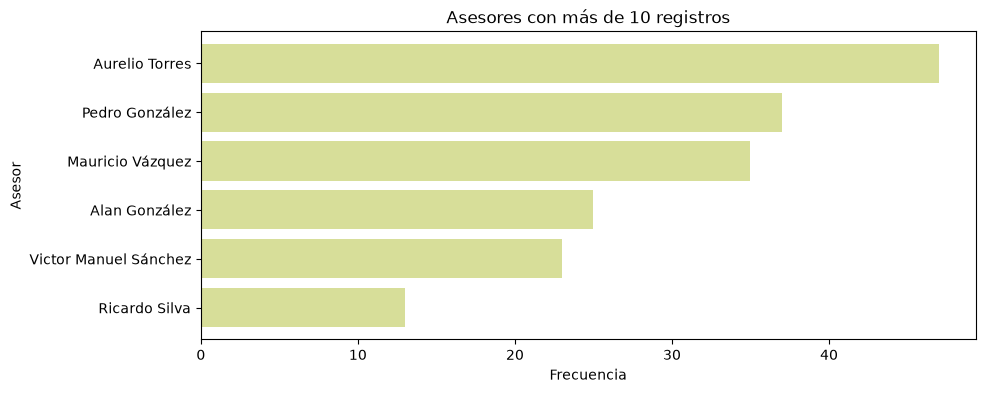

In [354]:
# Realizamos grafico de barras del dataframe filtrado
Filtro_index = Filtro_index.sort_values(by='count', ascending=True)
Filtro_index.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "#D7DE99", legend=False)
plt.title('Asesores con más de 10 registros')
plt.xlabel('Frecuencia')
plt.ylabel('Asesor')

In [347]:
# Para la de estatus de lead
bp["Esatus Lead"].unique()

<StringArray>
[     'Activo',    'Cerrado ',      'Venta ',   'Sin datos',       'Venta',
     'Cerrado',  'Finalizado',     'Activo ', 'Finalizado ',       'venta']
Length: 10, dtype: str

In [348]:
# Limpiar nombres columnas
bp["Esatus Lead"] = bp["Esatus Lead"].str.strip()
bp["Esatus Lead"] = bp["Esatus Lead"].str.title()

In [ ]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq2 = bp['Esatus Lead'].value_counts().reset_index()
Tabla_freq2

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
2,Sin Datos,11
3,Venta,6
4,Finalizado,4


In [350]:
# Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro2= Tabla_freq2[Tabla_freq2["Esatus Lead"] != "Sin Datos"]
Filtro2

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
3,Venta,6
4,Finalizado,4


In [351]:
# Ajusto el indice de mi dataframe
Filtro2_index= Filtro2.set_index('Esatus Lead')
Filtro2_index

,count
Esatus Lead,
Activo,168
Cerrado,18
Venta,6
Finalizado,4


<Axes: title={'center': 'Estatus del Lead'}, xlabel='Estatus Lead'>

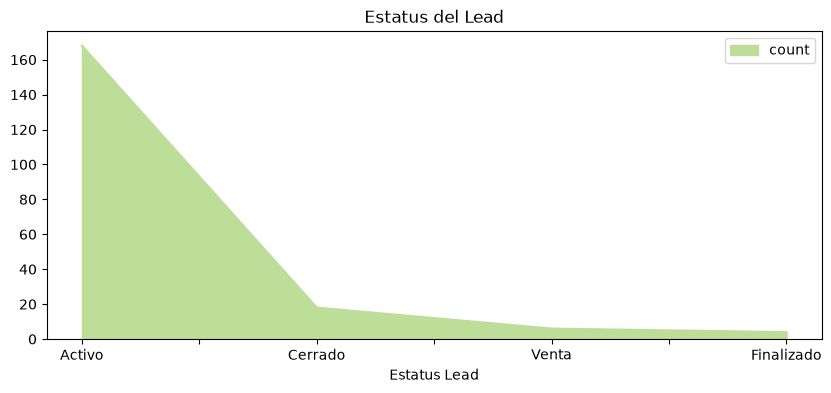

In [353]:
# Realizamos grafico de área del dataframe filtrado
Filtro2_index.plot(kind='area', figsize=(10,4),alpha = 1, color= "#BCDE99", title= "Estatus del Lead", xlabel= "Estatus Lead")

# **REGRESIÓN LINEAL SIMPLE**

Se mostrarán dos regresiones, una de la base de canales y otra de la base de SDC. De entre todas las bases trabajadas, consideramos que la información más importante se encuentra en estas bases.

Para la base de canales, en la que si se tenían valores nulos, se uso un filtro para seleccionar las dos columnas necesarias para la regresión y usar dropna para eliminar los nulos, pero para el análisis de correlación se uso solo la matriz con las columnas que se consideraron relevantes, y ahí sí no fue necesario el filtro (ya que si lo dejábamos, iba a marcar error por la diferencia de número de registros). A su vez, se sacó la regresión por canal, para ver si el las PDM impactaban en las ventas de forma diferente por canal, así como la correlación de las variables seleccionadas según el canal.

1. Base canales

In [355]:
df2 = df[['Ventas', 'Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas', "Canal"]]

In [356]:
# Filtrar filas sin nulos en las columnas que usa el modelo
df2 = df2.dropna(subset=['PDM', 'Ventas'])

<Axes: xlabel='PDM', ylabel='Ventas'>

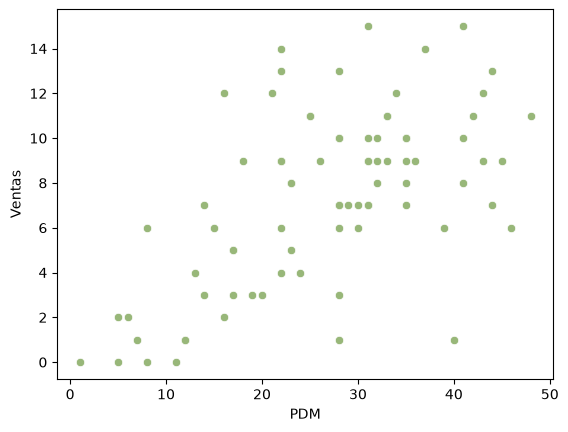

In [359]:
# Imprimimos el scatter plot entre la variable dependiente (total) e independiente (efectivos) 
# para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='PDM', y='Ventas', color="#98B779", data=df2)

In [361]:
# Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df2[['PDM']]
Var_Dep= df2['Ventas']

In [362]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [363]:
# Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PDM']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.833
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [364]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['PDM'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.20835036]),
 'rank_': np.int64(1),
 'singular_': array([98.9253366]),
 'intercept_': np.float64(1.8328817031755396)}

In [365]:
# Modelo matemático:
# y= 0.20835036(PDM)+1.8328817031755396

In [366]:
# Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.34918020751643963

In [367]:
# Predecimos los valores de formalizado a partir de la variable "PDM"
y_pred= model.predict(X=df2[['PDM']])
y_pred

array([ 6.41658971,  4.54143644,  9.12514445, 10.16689627,  7.6666919 ,
        9.12514445,  8.29174299,  7.6666919 ,  4.7497868 ,  7.04164081,
        8.50009335,  7.6666919 ,  8.70844372,  8.50009335,  7.6666919 ,
        8.91679408,  8.29174299,  7.87504226, 11.00029772,  8.29174299,
       11.83369918, 10.79194736,  6.41658971, 11.41699845,  7.6666919 ,
       10.37524663,  9.33349481, 11.20864809, 10.58359699,  5.16648753,
        2.04123207,  4.12473571,  2.87463352,  3.08298389,  5.37483789,
        3.49968462,  2.87463352,  5.79153862,  4.7497868 ,  6.41658971,
        7.6666919 ,  5.99988898,  6.62494008,  6.62494008, 11.00029772,
        9.54184517,  8.08339263, 10.37524663, 10.79194736,  8.70844372,
        5.58318826,  4.95813716,  9.9585459 ,  9.12514445,  8.08339263,
        8.29174299, 10.37524663,  4.33308607,  3.49968462,  3.29133425,
        5.37483789,  7.6666919 ,  6.41658971,  6.83329044,  5.16648753,
        5.37483789,  7.24999117,  6.20823935,  8.70844372,  8.29

In [368]:
# Insertamos la columna de predicciones en el DataFrame
df2.insert(0, 'Predicciones', y_pred)
df2

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Canal
0,6.416590,9.0,329,NaN,NaN,22.0,9.0,4.0,Piso
1,4.541436,4.0,19,NaN,NaN,13.0,28.0,16.0,Piso
2,9.125144,10.0,76,NaN,NaN,35.0,15.0,6.0,Piso
3,10.166896,1.0,87,NaN,NaN,40.0,38.0,16.0,Piso
4,7.666692,3.0,55,NaN,NaN,28.0,78.0,60.0,Piso
...,...,...,...,...,...,...,...,...,...
85,7.041641,11.0,980,618.0,16.0,25.0,78.0,36.0,Digital
86,9.125144,8.0,834,179.0,32.0,35.0,83.0,59.0,Digital
87,9.125144,9.0,667,170.0,30.0,35.0,140.0,103.0,Digital
88,7.666692,7.0,748,200.0,28.0,28.0,101.0,53.0,Digital


In [ ]:
# Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.34918020751643963

In [375]:
# Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.5909147210185575)

In [369]:
# Filtros por tipo de canal
piso = df2[df2['Canal'] == 'Piso']
plazas = df2[df2['Canal'] == 'Plazas']
digital = df2[df2['Canal'] == 'Digital']

<Axes: xlabel='PDM', ylabel='Ventas'>

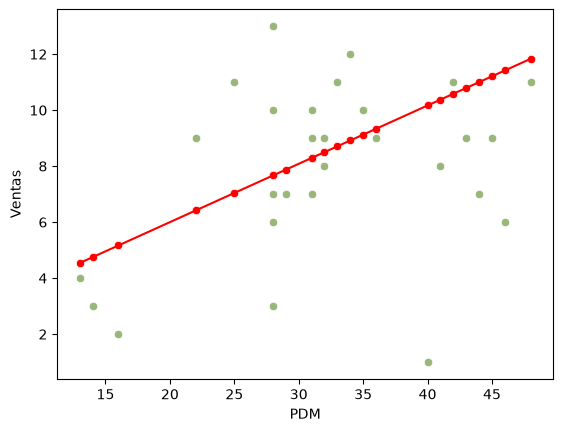

In [371]:
# Visualizamos la gráfica comparativa, por canal: piso
sns.scatterplot(x='PDM', y='Ventas', color="#98B779", data=piso)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=piso)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=piso)

<Axes: xlabel='PDM', ylabel='Ventas'>

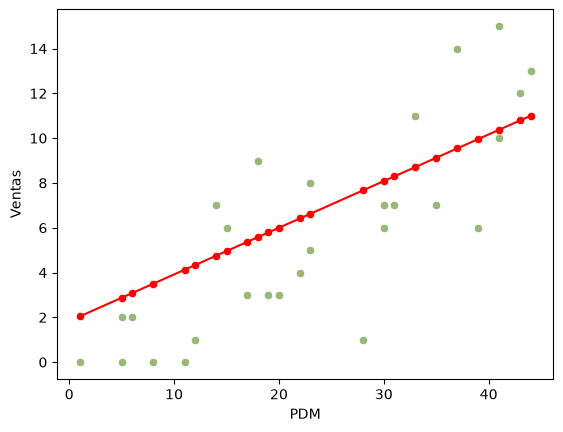

In [372]:
# Visualizamos la gráfica comparativa, por canal: plazas
sns.scatterplot(x='PDM', y='Ventas', color="#98B779", data=plazas)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=plazas)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=plazas)

<Axes: xlabel='PDM', ylabel='Ventas'>

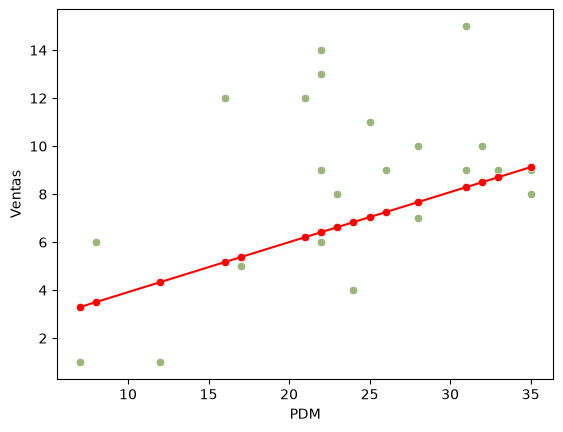

In [373]:
#Visualizamos la gráfica comparativa, por canal: digital
sns.scatterplot(x='PDM', y='Ventas', color="#98B779", data=digital)
sns.scatterplot(x='PDM', y='Predicciones', color="red", data=digital)
sns.lineplot(x='PDM', y='Predicciones', color="red", data=digital)

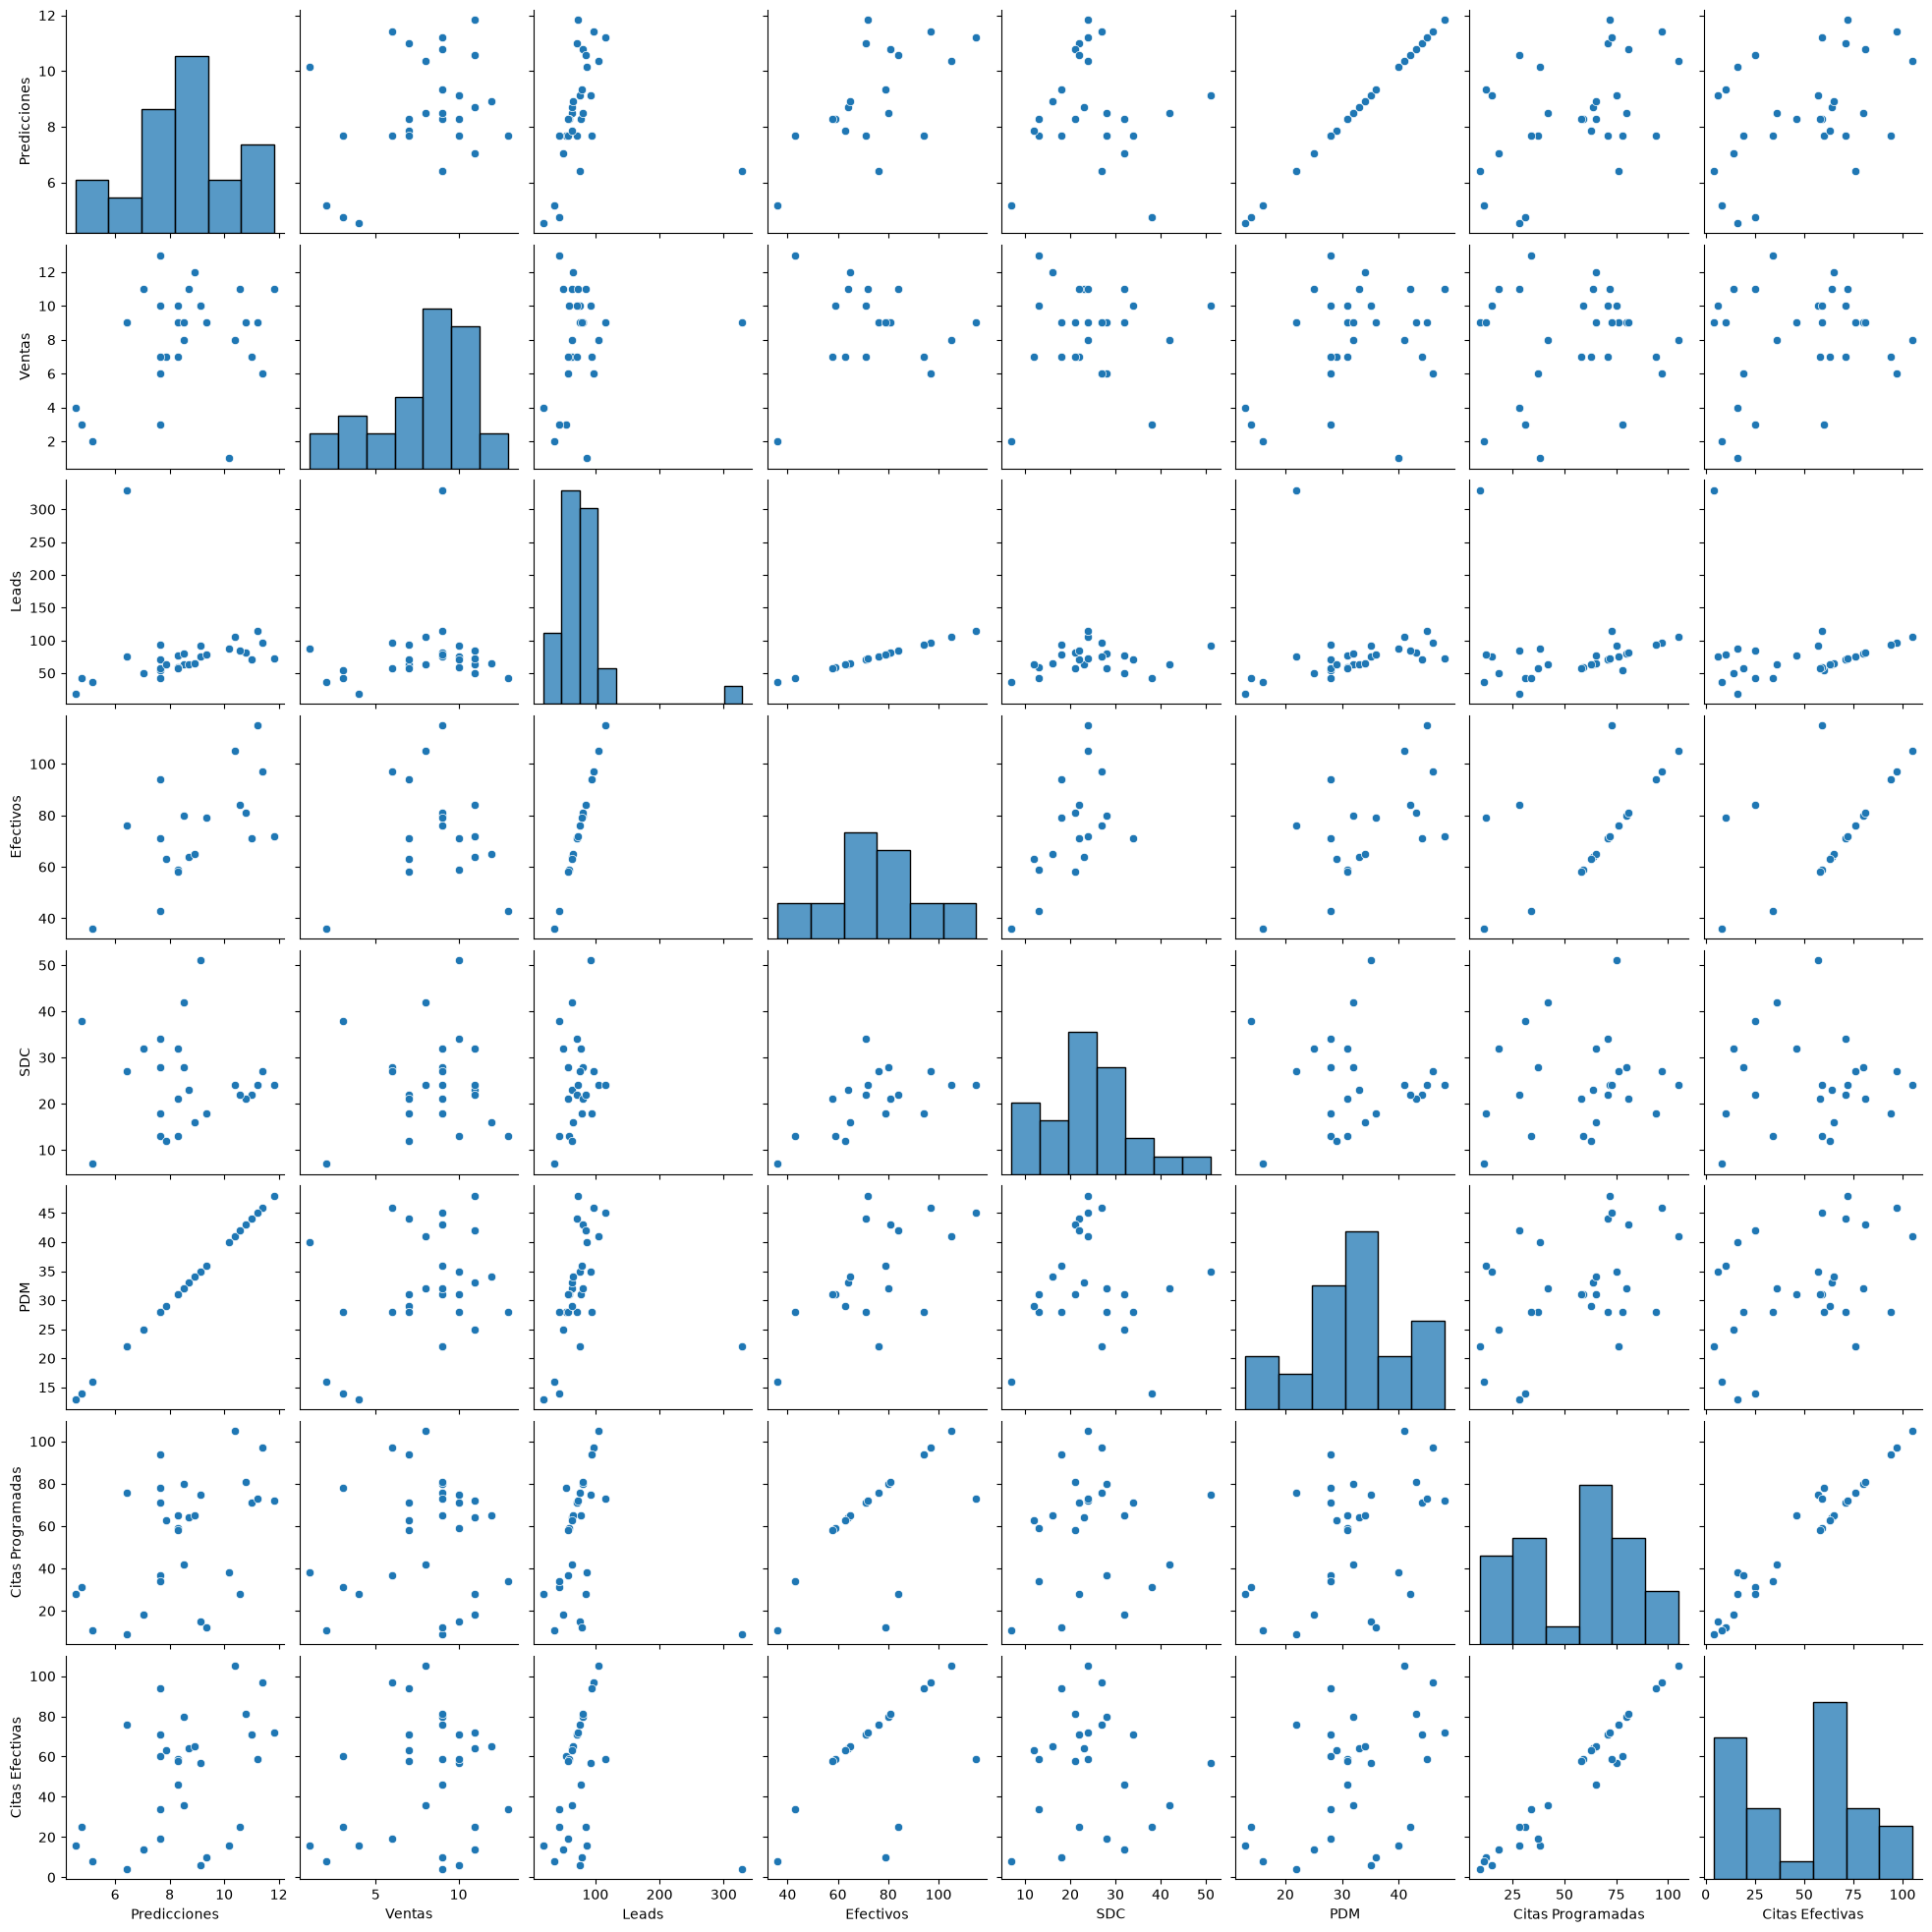

In [376]:
# Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(piso)

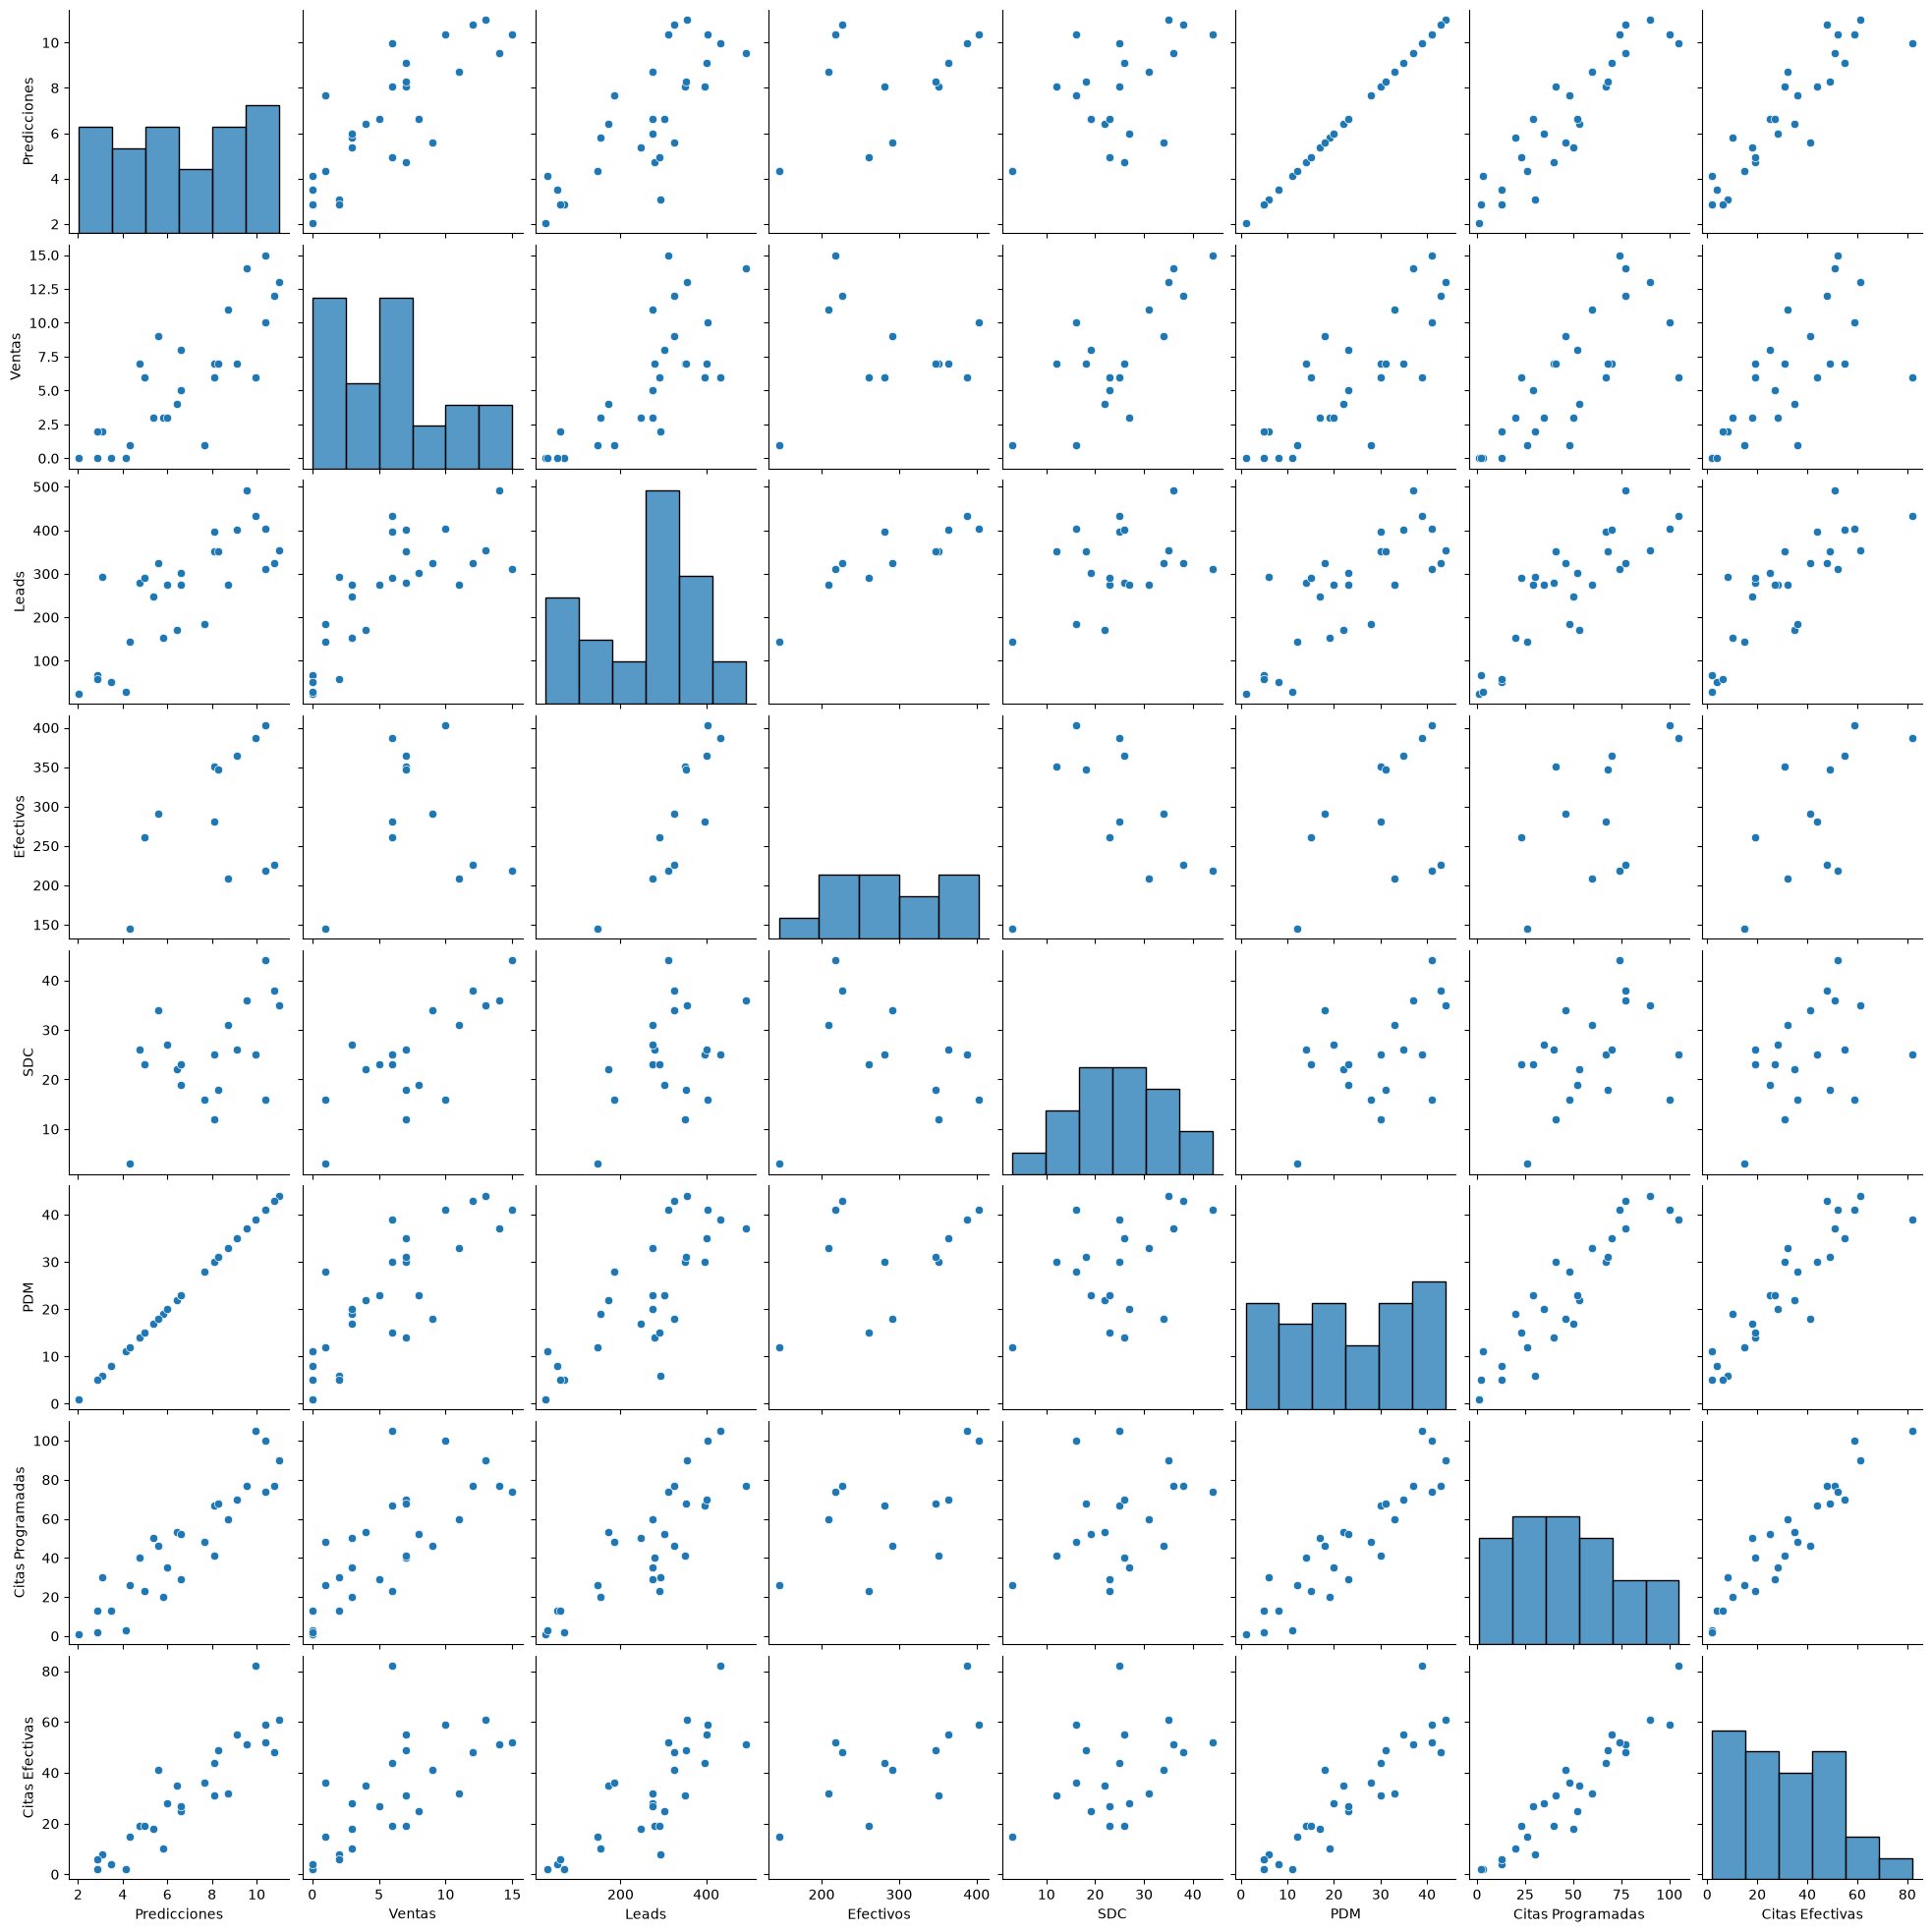

In [377]:
# Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(plazas)

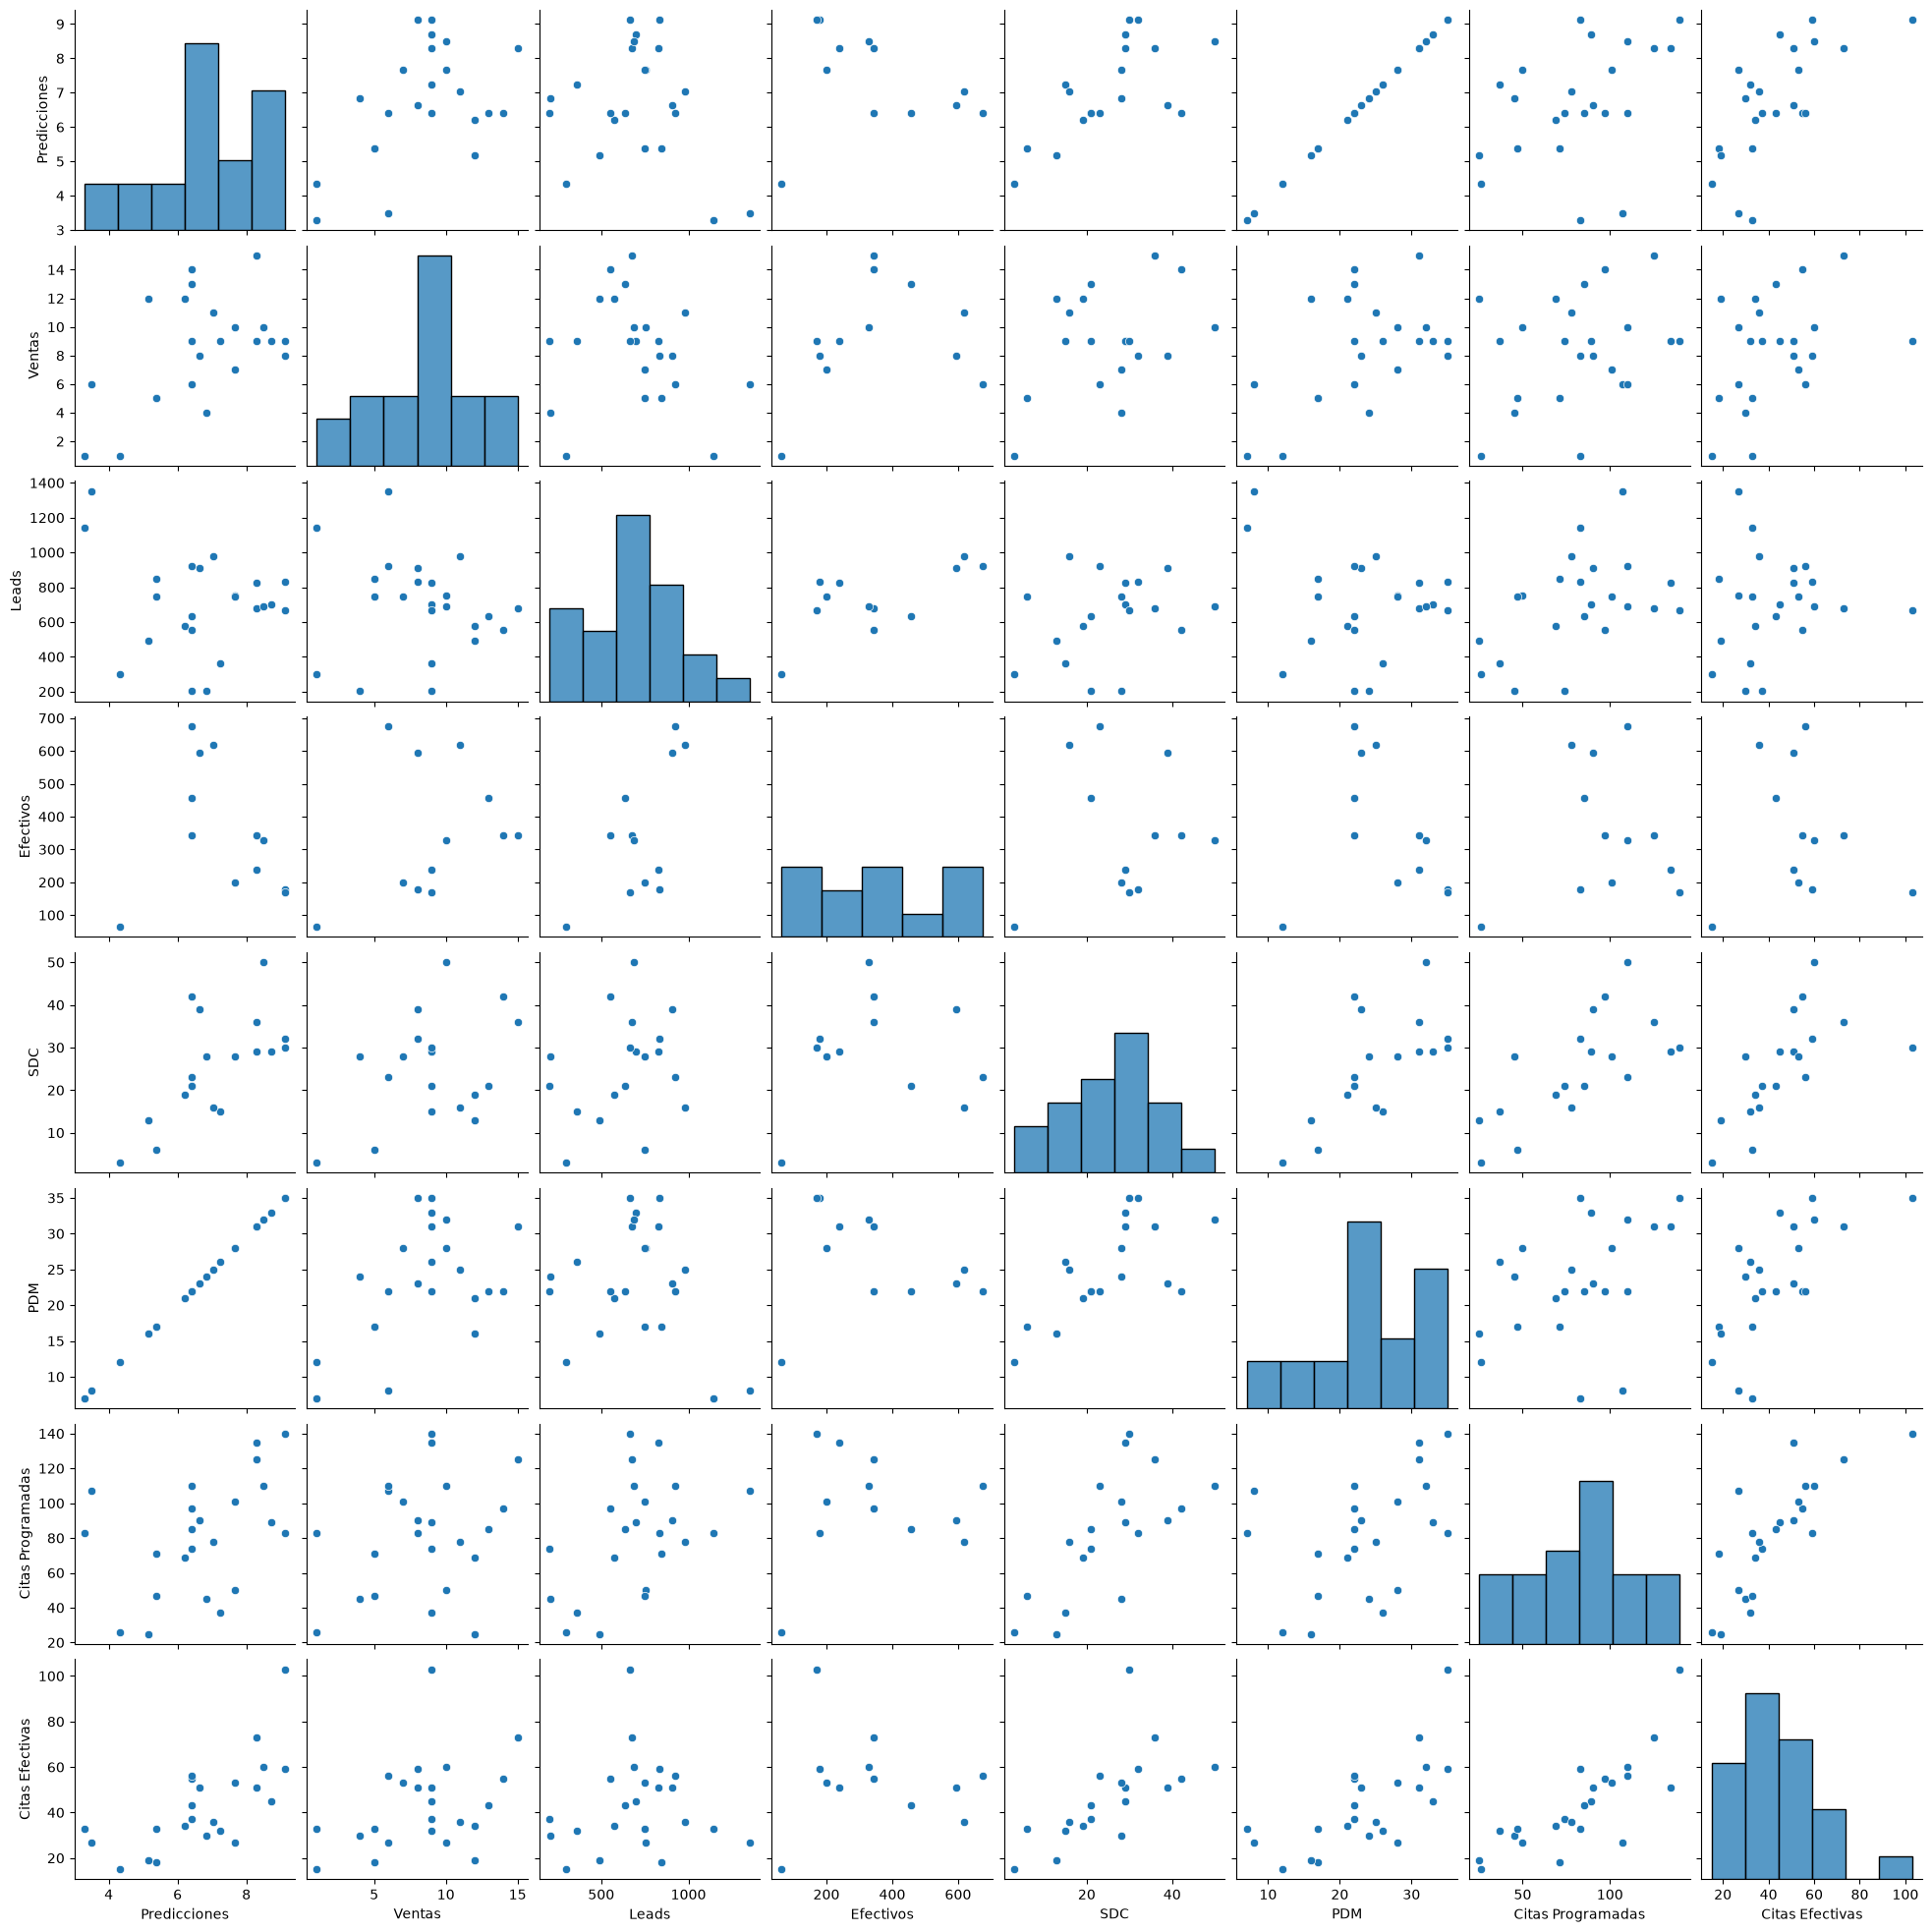

In [378]:
# Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(digital)

In [379]:
# Encontramos todas las correlaciones entre las variables - piso
variables = ["Predicciones", 'Ventas', 'Leads', 'Efectivos', 'SDC', 'PDM', 'Citas Programadas', 'Citas Efectivas']

corr_piso = piso[variables].corr()
corr_piso

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.322544,0.107513,0.620435,-0.010433,1.000000,0.458569,0.443342
Ventas,0.322544,1.000000,0.145890,0.016271,0.028472,0.322544,0.088814,0.184617
Leads,0.107513,0.145890,1.000000,0.999933,0.208464,0.107513,-0.068122,-0.064329
Efectivos,0.620435,0.016271,0.999933,1.000000,0.569352,0.620435,0.610394,0.542840
SDC,-0.010433,0.028472,0.208464,0.569352,1.000000,-0.010433,0.123659,-0.005231
PDM,1.000000,0.322544,0.107513,0.620435,-0.010433,1.000000,0.458569,0.443342
Citas Programadas,0.458569,0.088814,-0.068122,0.610394,0.123659,0.458569,1.000000,0.970845
Citas Efectivas,0.443342,0.184617,-0.064329,0.542840,-0.005231,0.443342,0.970845,1.000000


In [380]:
# Encontramos todas las correlaciones entre las variables - plazas
corr_plazas = plazas[variables].corr()
corr_plazas

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.816677,0.779603,0.395265,0.474937,1.000000,0.914045,0.903136
Ventas,0.816677,1.000000,0.760109,-0.022148,0.758338,0.816677,0.763436,0.701256
Leads,0.779603,0.760109,1.000000,0.865192,0.389000,0.779603,0.840662,0.812444
Efectivos,0.395265,-0.022148,0.865192,1.000000,-0.153417,0.395265,0.554582,0.658534
SDC,0.474937,0.758338,0.389000,-0.153417,1.000000,0.474937,0.381443,0.395948
PDM,1.000000,0.816677,0.779603,0.395265,0.474937,1.000000,0.914045,0.903136
Citas Programadas,0.914045,0.763436,0.840662,0.554582,0.381443,0.914045,1.000000,0.948359
Citas Efectivas,0.903136,0.701256,0.812444,0.658534,0.395948,0.903136,0.948359,1.000000


In [381]:
# Encontramos todas las correlaciones entre las variables - digital
corr_digital = digital[variables].corr()
corr_digital

,Predicciones,Ventas,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas
Predicciones,1.000000,0.494265,-0.203956,-0.195452,0.662097,1.000000,0.429418,0.683957
Ventas,0.494265,1.000000,-0.141695,0.291185,0.402287,0.494265,0.271744,0.371175
Leads,-0.203956,-0.141695,1.000000,0.661593,0.277646,-0.203956,0.471118,0.099760
Efectivos,-0.195452,0.291185,0.661593,1.000000,0.090996,-0.195452,0.088163,-0.096636
SDC,0.662097,0.402287,0.277646,0.090996,1.000000,0.662097,0.685919,0.648368
PDM,1.000000,0.494265,-0.203956,-0.195452,0.662097,1.000000,0.429418,0.683957
Citas Programadas,0.429418,0.271744,0.471118,0.088163,0.685919,0.429418,1.000000,0.793517
Citas Efectivas,0.683957,0.371175,0.099760,-0.096636,0.648368,0.683957,0.793517,1.000000


<Axes: >

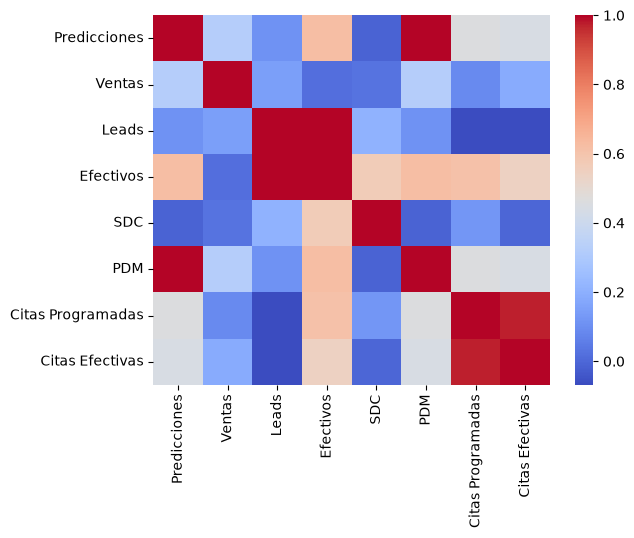

In [382]:
#Graficamos el mapa de calor de los coeficientes de correlación - piso
Heat_Map= sns.heatmap(corr_piso, cmap = 'coolwarm')  
Heat_Map

<Axes: >

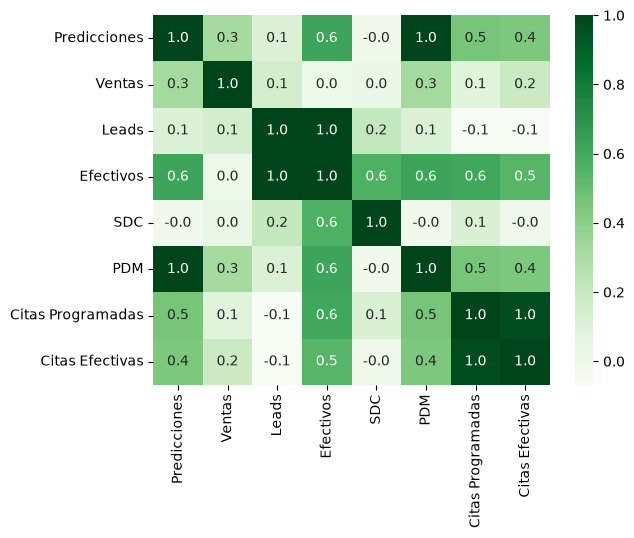

In [383]:
#Ajustamos el mapa de calor de los coeficientes de correlación - piso
Heat_Map= sns.heatmap(corr_piso, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

<Axes: >

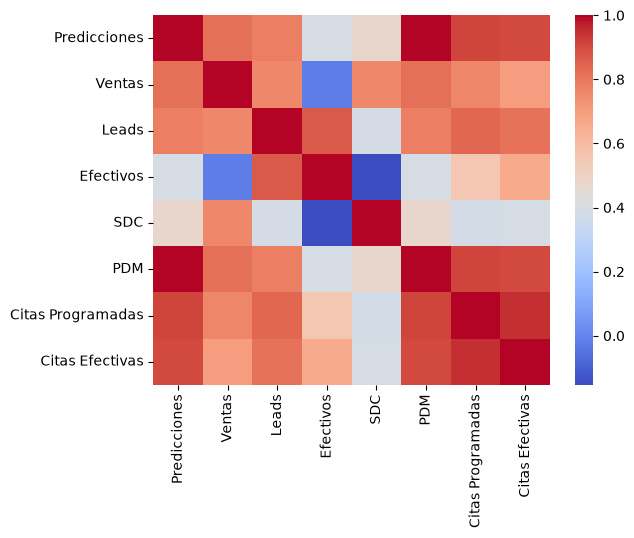

In [384]:
#Graficamos el mapa de calor de los coeficientes de correlación - plazas
Heat_Map= sns.heatmap(corr_plazas, cmap = 'coolwarm')  
Heat_Map

<Axes: >

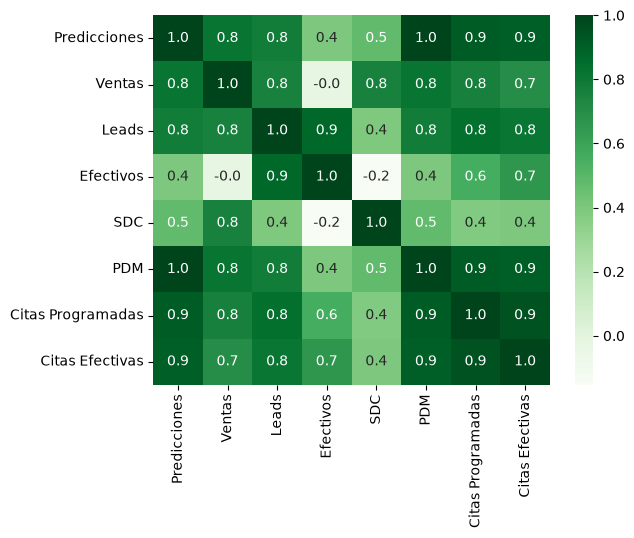

In [385]:
#Ajustamos el mapa de calor de los coeficientes de correlación - plazas
Heat_Map= sns.heatmap(corr_plazas, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

<Axes: >

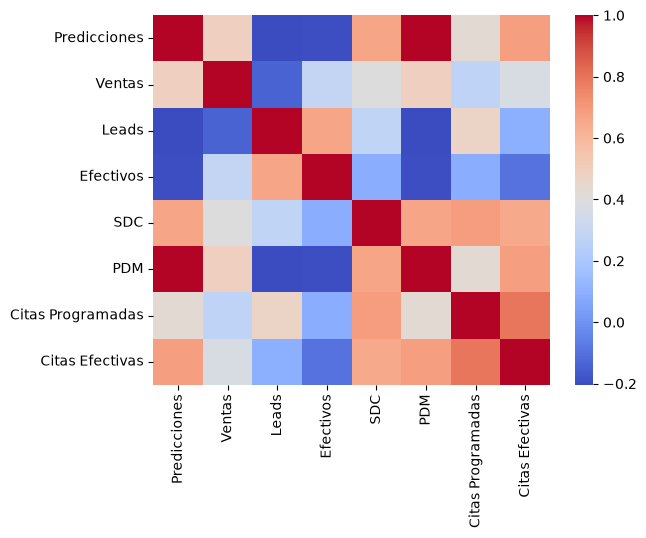

In [386]:
# Graficamos el mapa de calor de los coeficientes de correlación - digital
Heat_Map= sns.heatmap(corr_digital, cmap = 'coolwarm')  
Heat_Map

<Axes: >

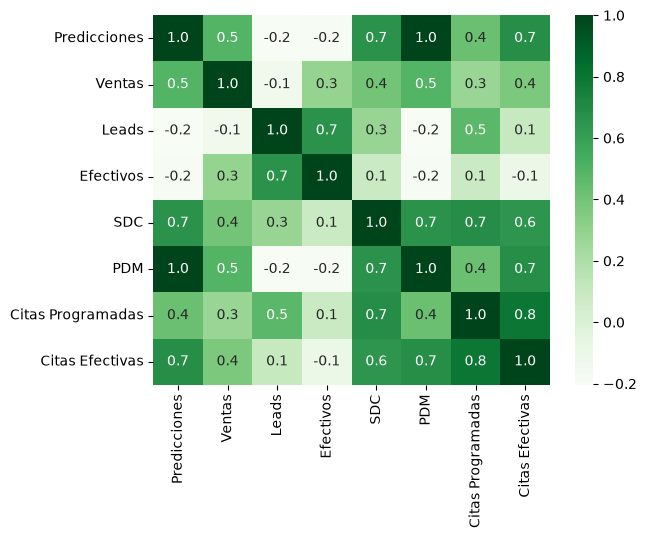

In [387]:
# Ajustamos el mapa de calor de los coeficientes de correlación - digital
Heat_Map= sns.heatmap(corr_digital, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

2. Base SDC

In [388]:
sdc2 = sdc[["Generadas", "Aprobadas", "Condicionadas", "Rechazadas", "Formalizadas"]]

<Axes: xlabel='Generadas', ylabel='Formalizadas'>

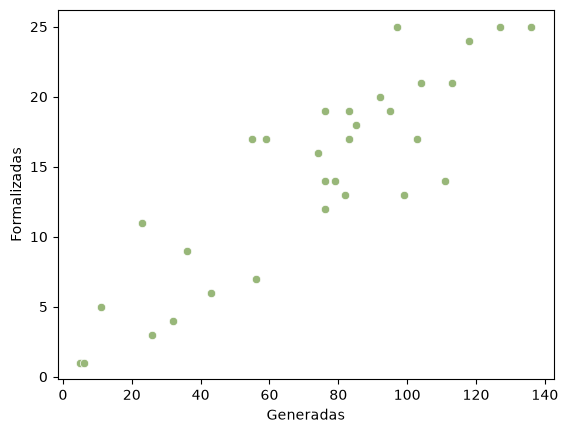

In [390]:
# Imprimimos el scatter plot entre la variable dependiente (Formalizadas) e independiente (Aprobadas) 
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Generadas', y='Formalizadas', color="#98B779", data=sdc2)

In [391]:
# Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= sdc2[['Generadas']]
Var_Dep= sdc2['Formalizadas']

In [392]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model1= LinearRegression()

In [393]:
# Ajustamos el modelo con las variables antes declaradas
model1.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Generadas']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [394]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model1.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Generadas'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.17397778]),
 'rank_': np.int64(1),
 'singular_': array([197.04281506]),
 'intercept_': np.float64(1.7302015117954284)}

In [395]:
# Modelo matemático:
# y= 0.17397778(Generadas)+1.7302015117954284

In [396]:
# Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model1.score(Vars_Indep,Var_Dep)

0.7754234907502584

In [397]:
# Predecimos los valores de formalizado a partir de la variable "Generadas"
y_pred= model1.predict(X=sdc2[['Generadas']])
y_pred

array([ 2.6000904 ,  2.77406817,  3.64395706,  5.73169038,  6.25362371,
        9.21124591, 11.29897923,  7.99340147, 11.47295701, 15.47444587,
       14.95251254, 19.64991251, 16.17035698, 14.95251254, 17.73615697,
       11.99489034, 14.95251254, 18.60604585, 19.82389029, 18.95400141,
       23.82537915, 25.39117914, 22.25957916, 21.04173473, 21.38969028,
       16.17035698, 16.51831253, 14.60455699, 18.2580903 , 15.9963792 ,
        7.29749037])

In [398]:
# Insertamos la columna de predicciones en el DataFrame
sdc2.insert(4, 'Predicciones', y_pred)
sdc2

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Predicciones,Formalizadas
0,5,1,0,4,2.600090,1
1,6,2,0,4,2.774068,1
2,11,7,1,4,3.643957,5
3,23,14,0,9,5.731690,11
4,26,8,4,14,6.253624,3
5,43,13,0,22,9.211246,6
6,55,30,3,17,11.298979,17
7,36,19,0,13,7.993401,9
8,56,26,1,13,11.472957,7
9,79,31,32,12,15.474446,14


<Axes: xlabel='Generadas', ylabel='Formalizadas'>

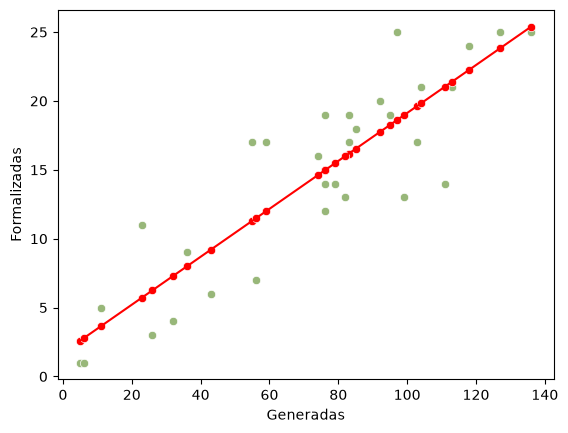

In [399]:
# Visualizamos la gráfica comparativa
sns.scatterplot(x='Generadas', y='Formalizadas', color="#98B779", data=sdc2)
sns.scatterplot(x='Generadas', y='Predicciones', color="red", data=sdc2)
sns.lineplot(x='Generadas', y='Predicciones', color="red", data=sdc2)

In [400]:
# Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model1.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.7754234907502584

In [401]:
# Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8805813368169112)

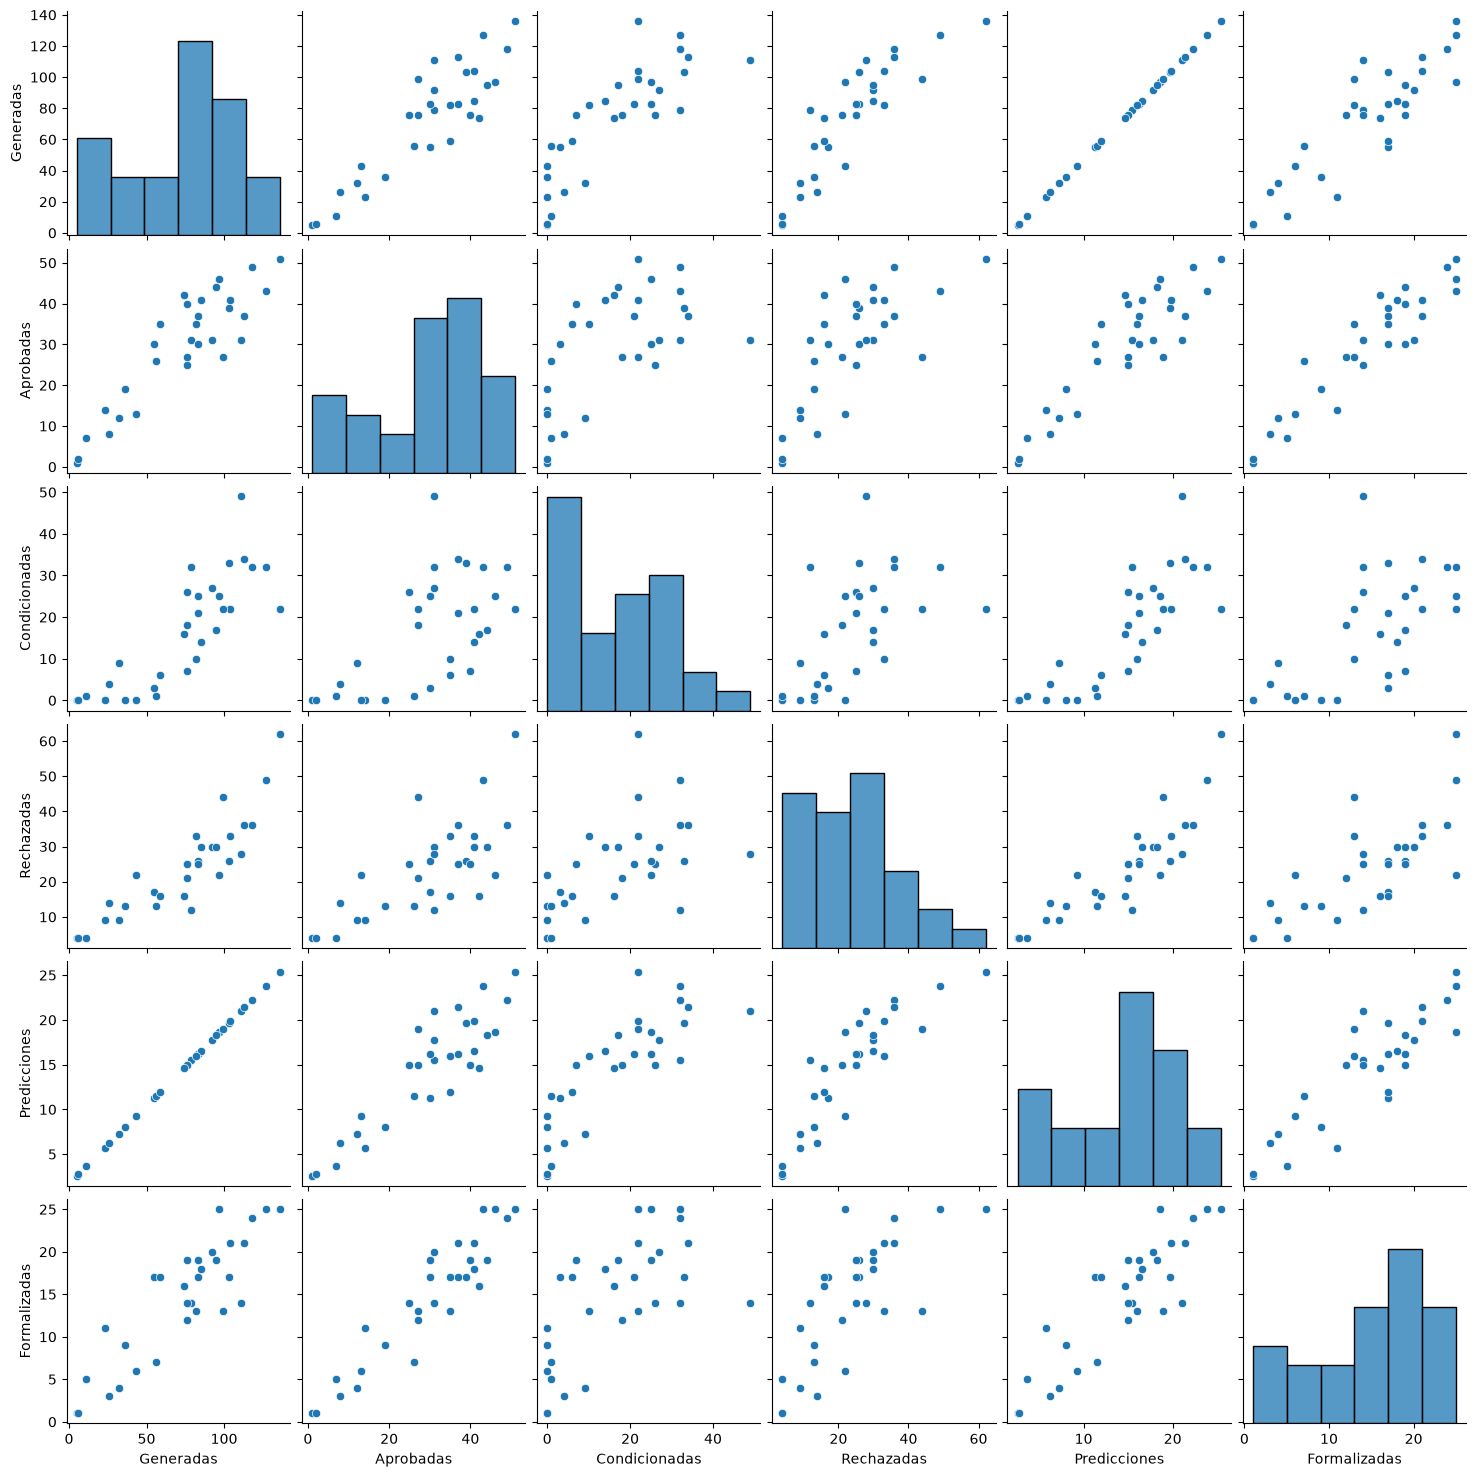

In [402]:
# Graficamos todas las dispersiones entre todas las variables, filtrado por canal
sns.pairplot(sdc2)

In [403]:
# Encontramos todas las correlaciones entre las variables 
Corr_Factors=sdc2.corr()
Corr_Factors

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Predicciones,Formalizadas
Indicador,,,,,,
Generadas,1.000000,0.896295,0.825762,0.881383,1.000000,0.880581
Aprobadas,0.896295,1.000000,0.609925,0.725853,0.896295,0.932941
Condicionadas,0.825762,0.609925,1.000000,0.588563,0.825762,0.647136
Rechazadas,0.881383,0.725853,0.588563,1.000000,0.881383,0.744203
Predicciones,1.000000,0.896295,0.825762,0.881383,1.000000,0.880581
Formalizadas,0.880581,0.932941,0.647136,0.744203,0.880581,1.000000


<Axes: xlabel='Indicador', ylabel='Indicador'>

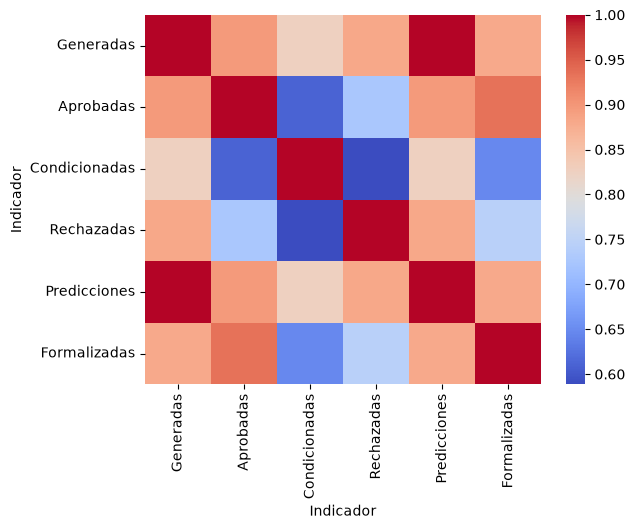

In [404]:
# Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'coolwarm')  
Heat_Map

<Axes: xlabel='Indicador', ylabel='Indicador'>

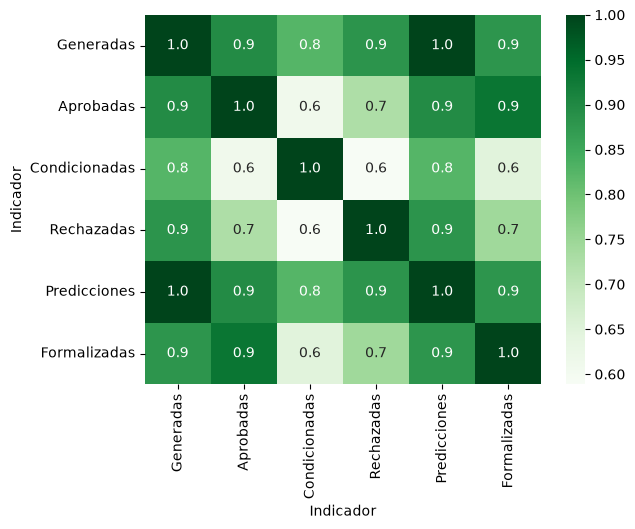

In [405]:
# Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors, cmap = 'Greens', annot=True, fmt=".1f")  
Heat_Map

# Hallazgos clave en general, sobre el socio formador
- El asesor con mayores registros es Aurelio Torres, con alrededor de 47 registros. Analizando el total de asesores, vemos que son pocos los que realizan más de 10 registros al mes.
- La mayoría de los leads se quedan en estatus “activo”, y son muy pocos los que avanzan a etapas de venta o finalizado (menos de 10), lo que sugiere que hay un cuello de botella entre la etapa de activo y cierre.
- Vemos que la relación entre las personas que toman la prueba de manejo, o programan las pruebas, si impacta en las ventas, aunque cambia según el canal: la relación más fuerte es en las que se programan/hace en plazas (r=0.8), después una relación moderada en el medio digital (r=0.5) y una muy débil en piso (r=3). Con esto vemos que la prueba de manejo no predice igual las ventas, pero convendría analizar qué se está haciendo en plazas para poder replicar eso en los demás canales. En los tres casos vemos que las citas programadas y efectivas se relacionan mucho entre sí, por lo que podríamos suponer que lo importante es hacer que la gente agende citas, más allá de la efectividad de estas. Igual se ve poca relación entre leads y leads efectivos, con las pruebas de manejo, mostrando que el contacto con los clientes pesa menos para las ventas que el que manejen y prueben el auto. 
- En la base de SDC de ventas, tenemos una correlación fuerte (r=0.9), analizado en embudo de crédito, en donde vemos que las solicitudes generadas predicen muy bien cuántas se terminan formalizando, por lo que vemos que el hecho de que los clientes realicen las solicitudes es una de las palancas más importantes para lograr cerrar una venta.
- La forma en que se generan las bases, ya sea que hagan el resgistro manual en un excel, o que las genere el mismo CRM que manejan con los registros que se hacen en el, están muy mal elaboradas. En muchos casos, más allá de las que se analizaron en este archivo de código, muchas bases tienen varios errores: la forma en que se ponen los títulos (con espacios, o sin nombres), nombres de columnas repetidos, ponen mucha información en una base (en la base de análisis de piso, venían datos de leads 2024, leads 2025, ventas 2024, ventas 2025, resumen general, todo en una misma hoja del excel), muchas filas en blanco, las primeras filas con encabezados para varias columnas o sumas de total por columna, tienen los datos al revés (cosas como indicadores están como registros en filas, y observaciones se encuentran como nombres de columnas), entre otras cosas. Sería un gran punto que se llevara a cabo un proceso de limpieza y normalización de las bases antes de que se haga cualquier análisis. Podría ser que, en caso de que las genere automáticamente el CRM, se cree un programa por el que todas las bases salidas del CRM tengan que pasar, en el que se haga un proceso de limpieza y normalización, para que las personas puedan trabajar con bases ya listas para el análisis.
- Otro gran punto, en especial en las bases que se tienen registros de leads, es que se aseguren de que los asesores lleven el registro MES a MES, para evitar que alguien que durante todo el año no tuvo ni un registro, luego tenga en diciembre que tuvo 1000. Esto con el fin de que se puedan realizar mejor los análisis.

# Propuestas del equipo
1. Estandarizar los procesos de limpieza y normalización de las bases, con un programa que permita realizar dichos procesos. Para ello, se tendría que diseñar un código estándar que el programa pueda seguir, y esto usarlo como paso intermedio: sale del CRM la base -> se mete al programa -> que pase un análisis para ver si quedó algún error que debería checarse manualmente -> sección para descargar la base ya limpia en el formato requerido (csv, excel, etc.).
2. Conectar las bases de Leads, Resumen y Bitácora de piso en un solo tablero que, en tiempo real, permita visualizar el embudo completo de los leads (Activo → Cerrado → Venta → Finalizado) y que permita disparar alertas automáticas cuando un lead lleva más de X días sin avanzar (que se quede abierto) a la Solicitud de Crédito. Podría ser que el mismo tablero indique los top 10 leads que tengan mayor probabilidad de ser efectivos, para que el equipo sepa cuales deben tener seguimiento priorizado. Por otro lado, que lance alertas a aquellos que siguen en la primera etapa del embudo, y que ya llevan mucho tiempo ahí, para que se analice si se deben descartar, o dar más seguimiento.
3. Comparativa entre asesores y productos: La idea es cruzar el desempeño por asesor (Base TDH), contra cierre por modelo de carro, con el fin que se puedan tomar decisiones de inventario y financiamiento basado en datos, y detectar rápido quién necesita coaching o quién tiene un método que vale la pena replicar con el resto del equipo.
4. Analizar las estrategias que se están siguiendo por canal, para ver cuáles son los puntos que facilitan que un cliente haga PDM y SDC, y que generen más ventas. Vemos que en plazas, el hecho de que la gente haga PDM si se relaciona mucho con que se llegue al punto de venta, y valdría la pena ver si es replicable la estrategia.